In [ ]:
import numpy as np

class DenseLayer:
    def __init__(self, input_size, output_size):
        self.input_size = input_size
        self.output_size = output_size

        self.weights = np.random.randn(output_size, input_size)
        self.biases = np.random.randn(output_size, 1)

    def sigmoid(self, x):

        return 1 / (1 + np.exp(-x))

    def forward(self, inputs):

        self.inputs = inputs
        z = np.dot(self.weights, inputs) + self.biases
        self.output = self.sigmoid(z)
        return self.output

/usr/local/lib/python3.10/dist-packages/keras/optimizers/legacy/gradient_descent.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/optimizers/legacy/adam.py:117: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/optimizers/legacy/rmsprop.py:143: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Epoch 1/100
4/4 [==============================] - 1s 5ms/step - loss: 3.7107
Epoch 2/100
4/4 [==============================] - 0s 3ms/step - loss: 1.2816
Epoch 3/100
4/4 [==============================] - 0s 3ms/step - loss: 0.7733
Epoch 4/100
4/4 [==============================] - 0s 3ms/step - loss: 0.6196
Epoch 5/100
4/4 [==============================] - 0s 3ms/step - loss: 0.5849
Epoch 6/100
4/4 [==============================] - 0s 3ms/step - loss: 0.5726
Epoch 7/100
4/4 [==============================] - 0s 3ms/step - loss: 0.5782
Epoch 8/100
4/4 [==============================] - 0s 3ms/step - loss: 0.5688
Epoch 9/100
4/4 [==============================] - 0s 3ms/step - loss: 0.5624
Epoch 10/100
4/4 [==============================] - 0s 3ms/step - loss: 0.5582
Epoch 11/100
4/4 [==============================] - 0s 3ms/step - loss: 0.5538
Epoch 12/100
4/4 [==============================] - 0s 3ms/step - loss: 0.5552
Epoch 13/100
4/4 [==============================] - 0s 3ms/st

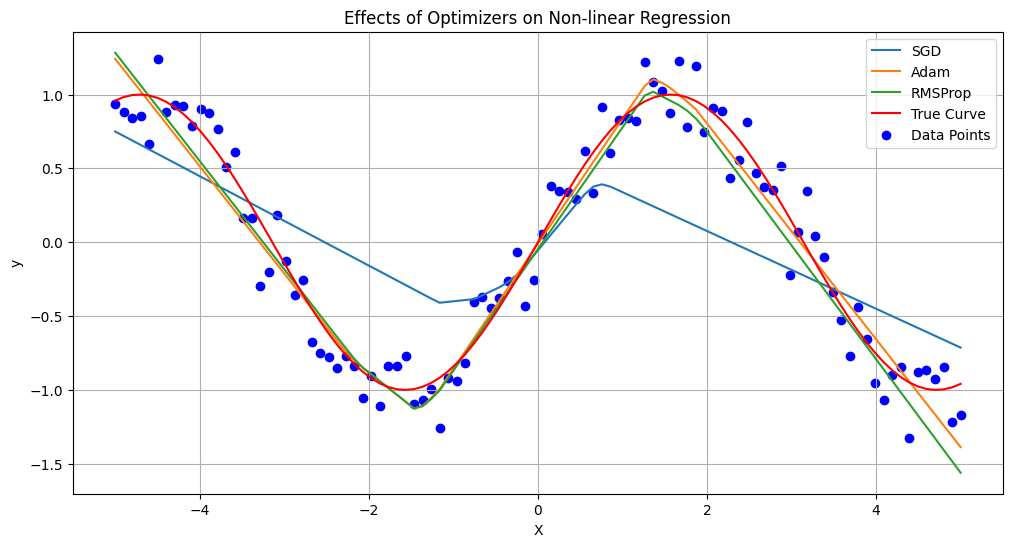

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD, Adam, RMSprop

# Generate the data
X = np.linspace(-5, 5, 100)
y = np.sin(X) + np.random.randn(100) * 0.2  # Non-linear relationship with noise

# Create a sequential model
model = Sequential()
model.add(Dense(units=10, activation='relu', input_shape=(1,)))
model.add(Dense(units=1))

# Define the optimizer options
optimizers = [SGD(lr=0.01), Adam(lr=0.01), RMSprop(lr=0.01)]
optimizer_names = ['SGD', 'Adam', 'RMSProp']

# Train and plot the models
plt.figure(figsize=(12, 6))
for optimizer, optimizer_name in zip(optimizers, optimizer_names):
    model.compile(loss='mean_squared_error', optimizer=optimizer)
    history = model.fit(X, y, epochs=100, verbose=1)
    predictions = model.predict(X)
    plt.plot(X, predictions, label=optimizer_name)

plt.plot(X, np.sin(X), color='r', label='True Curve')
plt.scatter(X, y, color='b', label='Data Points')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Effects of Optimizers on Non-linear Regression')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD, Adam, RMSprop, Adagrad

# Generate the data
X = np.linspace(-5, 5, 100)
y = np.sin(X) + np.random.randn(100) * 0.2  # Non-linear relationship with noise

# Create a sequential model
model = Sequential()
model.add(Dense(units=10, activation='relu', input_shape=(1,)))
model.add(Dense(units=1))

# Define the optimizer options
optimizers = [
    SGD(lr=0.01),
    Adam(lr=0.01),
    RMSprop(lr=0.01),
    Adagrad(lr=0.01),
    SGD(lr=0.01, momentum=0.9),  # SGD with momentum
]
optimizer_names = ['SGD', 'Adam', 'RMSProp', 'Adagrad', 'SGD with Momentum']

# Train and plot the models
plt.figure(figsize=(16, 10))
for optimizer, optimizer_name in zip(optimizers, optimizer_names):
    model.compile(loss='mean_squared_error', optimizer=optimizer)
    history = model.fit(X, y, epochs=100, verbose=1)
    predictions = model.predict(X)

    # Plotting the convergence
    plt.subplot(2, 1, 1)
    plt.plot(history.history['loss'], label=optimizer_name)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Convergence')
    plt.legend()

    # Plotting the predictions
    plt.subplot(2, 1, 2)
    plt.plot(X, predictions, label=optimizer_name)
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title('Effects of Optimizers on Non-linear Regression')
    plt.legend()

plt.subplot(2, 1, 1)
plt.grid(True)
plt.subplot(2, 1, 2)
plt.plot(X, np.sin(X), color='r', label='True Curve')
plt.scatter(X, y, color='b', label='Data Points')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Step 2: Load the Iris dataset
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target

# Step 3: Preprocess the data
# Encode the labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

# Step 4: Build the model
model = Sequential()
model.add(Dense(10, input_shape=(X.shape[1],), activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(y_categorical.shape[1], activation='softmax'))

# Step 5: Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Step 6: Train the model
model.fit(X_train, y_train, epochs=50, batch_size=5, validation_split=0.1)

# Step 7: Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy*100:.2f}%')

# Step 8: Make predictions
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

# Print the predictions and true values
print("Predicted classes:", predicted_classes)
print("True classes:", true_classes)


Epoch 1/50
22/22 [==============================] - 3s 26ms/step - loss: 1.4033 - accuracy: 0.1204 - val_loss: 1.1554 - val_accuracy: 0.4167
Epoch 2/50
22/22 [==============================] - 0s 14ms/step - loss: 1.2647 - accuracy: 0.4444 - val_loss: 1.0751 - val_accuracy: 0.7500
Epoch 3/50
22/22 [==============================] - 0s 7ms/step - loss: 1.1736 - accuracy: 0.5093 - val_loss: 1.0206 - val_accuracy: 0.8333
Epoch 4/50
22/22 [==============================] - 0s 12ms/step - loss: 1.1037 - accuracy: 0.5556 - val_loss: 0.9947 - val_accuracy: 0.8333
Epoch 5/50
22/22 [==============================] - 0s 9ms/step - loss: 1.0388 - accuracy: 0.5185 - val_loss: 0.9463 - val_accuracy: 0.9167
Epoch 6/50
22/22 [==============================] - 0s 9ms/step - loss: 0.9809 - accuracy: 0.6019 - val_loss: 0.8895 - val_accuracy: 1.0000
Epoch 7/50
22/22 [==============================] - 0s 5ms/step - loss: 0.9212 - accuracy: 0.8241 - val_loss: 0.8599 - val_accuracy: 0.9167
Epoch 8/50
22/22 

In [ ]:
# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Step 2: Load the Iris dataset
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target

# Step 3: Preprocess the data
# Encode the labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

# Step 4: Build the model
model = Sequential()
model.add(Dense(10, input_shape=(X.shape[1],), activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(y_categorical.shape[1], activation='softmax'))

# Step 5: Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Step 6: Train the model
model.fit(X_train, y_train, epochs=50, batch_size=5, validation_split=0.1)

# Step 7: Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy*100:.2f}%')

# Step 8: Make predictions
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

# Print the predictions and true values
print("Predicted classes:", predicted_classes)
print("True classes:", true_classes)

# Step 9: Take user input and predict the species
def predict_species(sepal_length, sepal_width, petal_length, petal_width):
    input_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    prediction = model.predict(input_data)
    predicted_class = np.argmax(prediction, axis=1)
    species = label_encoder.inverse_transform(predicted_class)
    return species[0]

# Get user input
sepal_length = float(input("Enter sepal length (in cm): "))
sepal_width = float(input("Enter sepal width (in cm): "))
petal_length = float(input("Enter petal length (in cm): "))
petal_width = float(input("Enter petal width (in cm): "))

# Predict the species
predicted_species = predict_species(sepal_length, sepal_width, petal_length, petal_width)
print(f"The predicted species is: {predicted_species}")


Epoch 1/50
22/22 [==============================] - 3s 40ms/step - loss: 1.5422 - accuracy: 0.3519 - val_loss: 1.4561 - val_accuracy: 0.1667
Epoch 2/50
22/22 [==============================] - 0s 8ms/step - loss: 1.1286 - accuracy: 0.3611 - val_loss: 1.1382 - val_accuracy: 0.1667
Epoch 3/50
22/22 [==============================] - 0s 21ms/step - loss: 1.0158 - accuracy: 0.4444 - val_loss: 1.0532 - val_accuracy: 0.2500
Epoch 4/50
22/22 [==============================] - 0s 17ms/step - loss: 0.9889 - accuracy: 0.5093 - val_loss: 1.0497 - val_accuracy: 0.2500
Epoch 5/50
22/22 [==============================] - 0s 15ms/step - loss: 0.9700 - accuracy: 0.4722 - val_loss: 1.0438 - val_accuracy: 0.1667
Epoch 6/50
22/22 [==============================] - 1s 26ms/step - loss: 0.9461 - accuracy: 0.5093 - val_loss: 1.0225 - val_accuracy: 0.2500
Epoch 7/50
22/22 [==============================] - 0s 19ms/step - loss: 0.9251 - accuracy: 0.5556 - val_loss: 1.0005 - val_accuracy: 0.2500
Epoch 8/50
22/

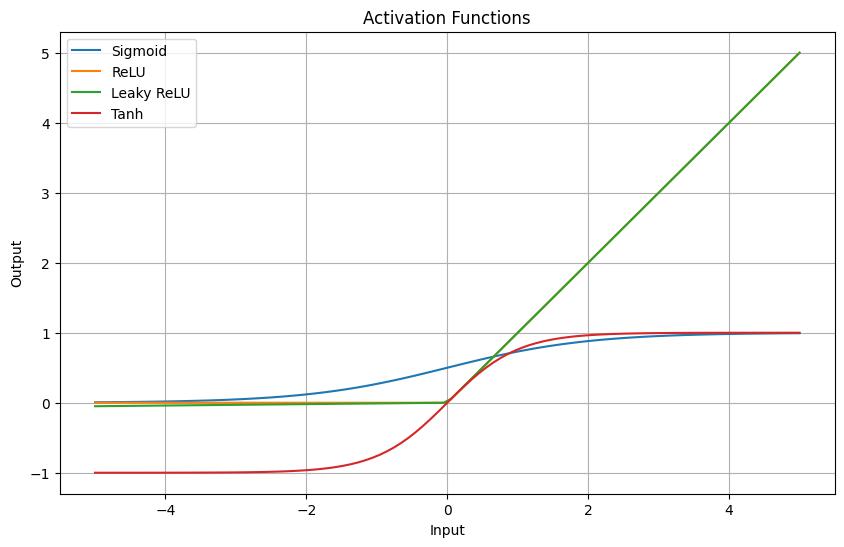

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid Function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# ReLU Function
def relu(x):
    return np.maximum(0, x)

# Leaky ReLU Function
def leaky_relu(x):
    return np.maximum(0.01 * x, x)

# Tanh Function
def tanh(x):
    return np.tanh(x)

# Softmax Function
def softmax(x):
    exps = np.exp(x)
    return exps / np.sum(exps)

# Generate input data
x = np.linspace(-5, 5, 100)

# Calculate activation function outputs
sigmoid_output = sigmoid(x)
relu_output = relu(x)
leaky_relu_output = leaky_relu(x)
tanh_output = tanh(x)

# Plotting the activation functions
plt.figure(figsize=(10, 6))
plt.plot(x, sigmoid_output, label='Sigmoid')
plt.plot(x, relu_output, label='ReLU')
plt.plot(x, leaky_relu_output, label='Leaky ReLU')
plt.plot(x, tanh_output, label='Tanh')
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Activation Functions')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import seaborn as sns
titanic_df = sns.load_dataset('titanic')
titanic_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
import numpy as np


input_size = 3
batch_size = 2
input_data = np.random.randn(input_size, batch_size)

dense_layer = DenseLayer(input_size, output_size=2)
output = dense_layer.forward(input_data)

print("Input data:")
print(input_data)

print("\nOutput data:")
print(output)


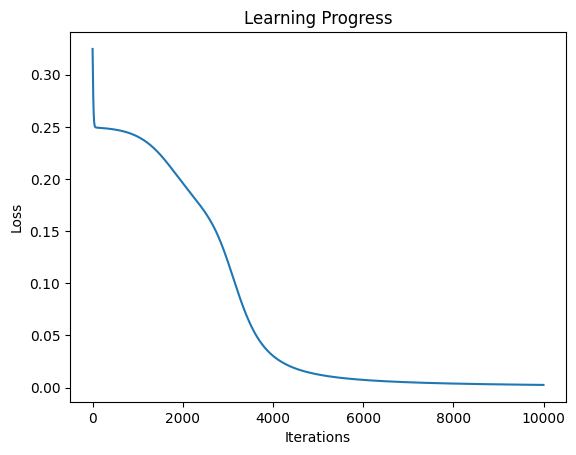

Final Output after Training:
[[0.05322146]
 [0.95171535]
 [0.95160449]
 [0.05175396]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])

Y = np.array([[0],
              [1],
              [1],
              [0]])

np.random.seed(42)

input_size = 2
output_size = 1
hidden_layer_size = 2

weights_input_hidden = np.random.uniform(size=(input_size, hidden_layer_size))
biases_input_hidden = np.random.uniform(size=(1, hidden_layer_size))

weights_hidden_output = np.random.uniform(size=(hidden_layer_size, output_size))
biases_hidden_output = np.random.uniform(size=(1, output_size))

learning_rate = 0.1
num_iterations = 10000

losses = []


for iteration in range(num_iterations):
    hidden_layer_input = np.dot(X, weights_input_hidden) + biases_input_hidden
    hidden_layer_output = sigmoid(hidden_layer_input)

    output_layer_input = np.dot(hidden_layer_output, weights_hidden_output) + biases_hidden_output
    predicted_output = sigmoid(output_layer_input)


    loss = np.mean((Y - predicted_output) ** 2)
    losses.append(loss)


    output_error = Y - predicted_output
    output_delta = output_error * sigmoid_derivative(predicted_output)

    hidden_error = output_delta.dot(weights_hidden_output.T)
    hidden_delta = hidden_error * sigmoid_derivative(hidden_layer_output)


    weights_hidden_output += hidden_layer_output.T.dot(output_delta) * learning_rate
    biases_hidden_output += np.sum(output_delta, axis=0, keepdims=True) * learning_rate

    weights_input_hidden += X.T.dot(hidden_delta) * learning_rate
    biases_input_hidden += np.sum(hidden_delta, axis=0, keepdims=True) * learning_rate

plt.plot(losses)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Learning Progress')
plt.show()

print("Final Output after Training:")
print(predicted_output)


1/1 [==============================] - 0s 234ms/step
Activation Function: relu, Accuracy: 0.9667
1/1 [==============================] - 0s 103ms/step
Activation Function: sigmoid, Accuracy: 0.9333
1/1 [==============================] - 0s 61ms/step
Activation Function: tanh, Accuracy: 0.9667
1/1 [==============================] - 0s 51ms/step
Activation Function: softmax, Accuracy: 0.9333


1/1 [==============================] - 0s 56ms/step


<ipython-input-2-bb13e435c9af>:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accuracy_dict.keys()), y=list(accuracy_dict.values()), palette="viridis")


Activation Function: linear, Accuracy: 0.9667


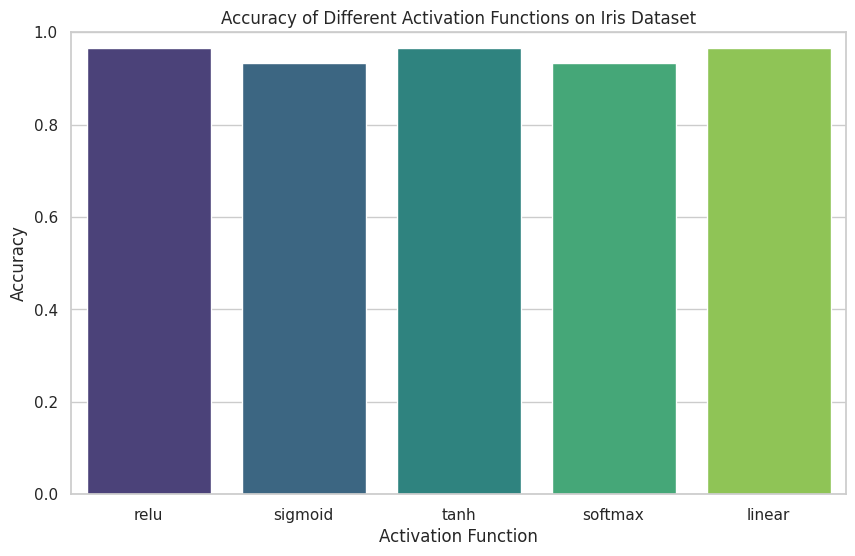

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Load the Iris dataset from sklearn
data = load_iris()
X, y = data.data, data.target

# Preprocess the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Encode the target variable
encoder = LabelEncoder()
y = encoder.fit_transform(y)
y = to_categorical(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# List of activation functions to test
activation_functions = ['relu', 'sigmoid', 'tanh', 'softmax', 'linear']

# Dictionary to store the accuracy for each activation function
accuracy_dict = {}

# Function to build and compile the model
def build_model(activation):
    model = Sequential()
    model.add(Dense(64, input_dim=X_train.shape[1], activation=activation))
    model.add(Dense(3, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Train and evaluate the model for each activation function
for activation in activation_functions:
    model = build_model(activation)
    model.fit(X_train, y_train, epochs=50, verbose=0)
    y_pred = np.argmax(model.predict(X_test), axis=1)
    y_test_labels = np.argmax(y_test, axis=1)
    accuracy = accuracy_score(y_test_labels, y_pred)
    accuracy_dict[activation] = accuracy
    print(f'Activation Function: {activation}, Accuracy: {accuracy:.4f}')

# Plot the results using Seaborn
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(x=list(accuracy_dict.keys()), y=list(accuracy_dict.values()), palette="viridis")
plt.xlabel('Activation Function')
plt.ylabel('Accuracy')
plt.title('Accuracy of Different Activation Functions on Iris Dataset')
plt.ylim(0, 1)
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

# Function to plot sample images
def plot_sample(X, y, index):
    plt.figure(figsize=(15, 2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

# Plot sample images from the training set
plot_sample(X_train, y_train, 0)
plot_sample(X_train, y_train, 1)

# Normalize the images to values between 0 and 1
X_train = X_train / 255.0
X_test = X_test / 255.0

# Build a simple artificial neural network for image classification
ann = models.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10, activation='softmax')
])
ann.compile(optimizer='SGD', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
ann.fit(X_train, y_train, epochs=5)

# Evaluate the ANN model
from sklearn.metrics import confusion_matrix, classification_report
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]
print("Classification Report: \n", classification_report(y_test, y_pred_classes))

# Build a convolutional neural network to train the images
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.fit(X_train, y_train, epochs=10)

# Evaluate the CNN model
cnn.evaluate(X_test, y_test)

y_pred = cnn.predict(X_test)
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]
y_test[:5]

plot_sample(X_test, y_test, 3)
classes[y_classes[3]]
classes[y_classes[2]]


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 150s 95ms/step - accuracy: 0.3080 - loss: 1.9303
Epoch 2/5
1217/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 107ms/step - accuracy: 0.4106 - loss: 1.6647

In [ ]:
import numpy as np
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load the IMDb movie review dataset
max_words = 10000
maxlen = 100

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_words)

# Pad sequences to a fixed length
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

# Build the LSTM model
model = Sequential()
model.add(Embedding(max_words, 50, input_length=maxlen))
model.add(LSTM(50))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(x_test, y_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')


17464789/17464789 [==============================] - 0s 0us/step
Epoch 1/5
313/313 [==============================] - 33s 97ms/step - loss: 0.4525 - accuracy: 0.7773 - val_loss: 0.3514 - val_accuracy: 0.8368
Epoch 2/5
313/313 [==============================] - 30s 96ms/step - loss: 0.2596 - accuracy: 0.8953 - val_loss: 0.3937 - val_accuracy: 0.8392
Epoch 3/5
313/313 [==============================] - 29s 94ms/step - loss: 0.1914 - accuracy: 0.9271 - val_loss: 0.4054 - val_accuracy: 0.8344
Epoch 4/5
313/313 [==============================] - 31s 99ms/step - loss: 0.1405 - accuracy: 0.9488 - val_loss: 0.4738 - val_accuracy: 0.8352
Epoch 5/5
782/782 [==============================] - 15s 19ms/step - loss: 0.5910 - accuracy: 0.8271
Test Loss: 0.5909629464149475, Test Accuracy: 0.8270800113677979
